# Import Libraries

In [ ]:
# Import Iibraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # prevent line wrapping

# Mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Datasets Loading

In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Sharpneer Tech/Projects/Python + Sql +Power Bi/shopping_behavior_Dataset.csv")

In [ ]:
# First Look of Data
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# **Checking Dataset**

In [ ]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Customer ID             3900 non-null   int64 
 1   Age                     3900 non-null   int64 
 2   Gender                  3900 non-null   object
 3   Item Purchased          3900 non-null   object
 4   Category                3900 non-null   object
 5   Purchase Amount (USD)   3900 non-null   int64 
 6   Location                3900 non-null   object
 7   Size                    3900 non-null   object
 8   Color                   3900 non-null   object
 9   Season                  3900 non-null   object
 10  Review Rating           3773 non-null   object
 11  Subscription Status     3900 non-null   object
 12  Shipping Type           3900 non-null   object
 13  Discount Applied        3900 non-null   object
 14  Promo Code Used         3900 non-null   object
 15  Prev

In [ ]:
# Review Ratig is object datatype...so we change it to float value
df['Review Rating'] = df['Review Rating'].astype('float')

In [ ]:
# Checking Null Values
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


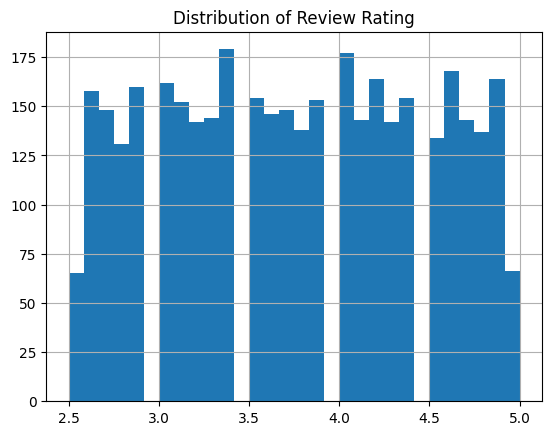

In [ ]:
# Checking the distribution before replace nan values
df['Review Rating'].hist(bins=30)
plt.title("Distribution of Review Rating")
plt.show()

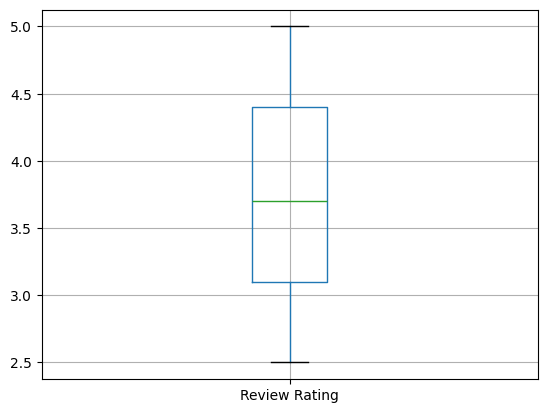

In [ ]:
# Check for outliers
df.boxplot(column='Review Rating')
plt.show()

In [ ]:
# The distribution is normal..also had no outliers...so we replace with mean value
df['Review Rating'] = df.groupby("Category")["Review Rating"].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# Again Checking the Dataset
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


# **Feature Engineering**

In [ ]:
# Rename the Columns
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")
df.rename(columns = {'purchase_amount_(usd)':'purchase_amount'},inplace = True)
df.columns


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [ ]:
# Create Purchase Frequency Score Column
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [ ]:
# Repalce same meaning value
df['frequency_of_purchases']= df['frequency_of_purchases'].replace({"Bi-Weekly":"Fortnightly","Every 3 Months":"Quarterly"})

In [ ]:
#Assign Scores to frequency of purchase
map ={
    'Weekly':7,
    'Fortnightly':14,
    'Monthly':30,
    'Quarterly':90,
    'Annually':365
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(map)

In [ ]:
# CHECK THE CHANGE
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [ ]:
# Promo code applied means discount applied....so we will check both the column value are same or not
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [ ]:
df = df.drop('promo_code_used', axis = 1)

In [ ]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'purchase_frequency_days'],
      dtype='object')

In [ ]:
# Create rating category
def rating_category(rating):
  if rating >= 4.5:
    return 'Excelent'
  elif rating >= 4.0:
    return 'Good'
  elif rating >= 3.0:
    return 'Neutral'
  else:
    return 'Poor'

df['rating_category'] = df['review_rating'].apply(rating_category)

In [ ]:
# CHECK THE CHANGE
df[['rating_category','review_rating']].head(10)

,rating_category,review_rating
0,Neutral,3.100000
1,Neutral,3.100000
2,Neutral,3.100000
3,Neutral,3.500000
4,Poor,2.700000
5,Poor,2.900000
6,Neutral,3.200000
7,Neutral,3.722606
8,Poor,2.600000
9,Excelent,4.800000


In [ ]:
# Create Age Group
labels = ['Young','Adult','Middle Aged','Senior']
df['age_group'] = pd.qcut(df['age'],q=4,labels=labels)

In [ ]:
# # CHECK THE CHANGE
df[['age_group','age']].head(10)

,age_group,age
0,Middle Aged,55
1,Young,19
2,Middle Aged,50
3,Young,21
4,Middle Aged,45
5,Middle Aged,46
6,Senior,63
7,Young,27
8,Young,26
9,Middle Aged,57


In [ ]:
df.to_csv("customer_data_cleaned.csv", index=False)

# **Now Connect and load our data to mysql**

In [ ]:
!pip install pymysql sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.2 MB/s eta 0:00:00


In [ ]:
# Install mysql server
!apt-get update
!apt-get install mysql-server
# Start the service
!service mysql start

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,870 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get

In [ ]:
from sqlalchemy import create_engine

# replace with your credentials
username = 'root'
password = 'Password'
host = '127.0.0.1'
database = 'customer_behaviour'


engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}/{database}')

df.to_sql('customer', con=engine, if_exists='replace', index=False)

OperationalError: (pymysql.err.OperationalError) (1698, "Access denied for user 'root'@'localhost'")
(Background on this error at: https://sqlalche.me/e/20/e3q8)